## Imports and Setup

In [2]:
import os
from pathlib import Path
import torch
import torch.nn as nn
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc
import json
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

print("All imports successful!")

All imports successful!


## Configuration

In [11]:
# Paths
DATA_ROOT = './data'
CHECKPOINT_DIR = Path('/Users/tiger.c/Desktop/URPS/diffusion_anomaly_score/score_demo/checkpoints')

RESULTS_DIR = Path('./test_results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Testing parameters
BATCH_SIZE = 128
SIGMA_MIN = 0.01
SIGMA_MAX = 0.3

# Output directories
ROC_DIR = RESULTS_DIR / 'roc_curves'
AUROC_DIR = RESULTS_DIR / 'auroc_scores'
METRICS_DIR = RESULTS_DIR / 'metrics_per_digit'
SUMMARY_DIR = RESULTS_DIR / 'summary'

for d in [ROC_DIR, AUROC_DIR, METRICS_DIR, SUMMARY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Checkpoint dir exists: {CHECKPOINT_DIR.exists()}")
print(f"Results dir: {RESULTS_DIR}")

Using device: cpu
Checkpoint dir: /Users/tiger.c/Desktop/URPS/diffusion_anomaly_score/score_demo/checkpoints
Checkpoint dir exists: True
Results dir: test_results


## Model Architecture (ScoreNet)

In [4]:
class ScoreNet(torch.nn.Module):
    """
    Neural network that learns the score function.
    
    Input:
      x_tilde: [B, 1, 28, 28] noisy image
      sigma:   [B] noise level
    Output:
      score:   [B, 1, 28, 28] predicted score field
    """
    def __init__(self, base_channels=64):
        super().__init__()
        c = base_channels
        
        # 2 input channels: image + log_sigma channel
        self.conv1 = torch.nn.Conv2d(2, c, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv2d(c, c, kernel_size=3, padding=1)
        self.conv3 = torch.nn.Conv2d(c, c, kernel_size=3, padding=1)
        self.conv4 = torch.nn.Conv2d(c, 1, kernel_size=3, padding=1)
        
        self.gn1 = torch.nn.GroupNorm(8, c)
        self.gn2 = torch.nn.GroupNorm(8, c)
        self.gn3 = torch.nn.GroupNorm(8, c)
    
    def forward(self, x_tilde, sigma):
        # sigma is [B], convert to [B,1,1,1]
        sigma_broadcast = sigma.view(-1, 1, 1, 1)
        log_sigma = torch.log(sigma_broadcast + 1e-12)
        
        # expand to an image-sized channel
        sigma_channel = log_sigma.expand(-1, 1, x_tilde.shape[2], x_tilde.shape[3])
        h = torch.cat([x_tilde, sigma_channel], dim=1)
        
        h = torch.nn.functional.silu(self.gn1(self.conv1(h)))
        h = torch.nn.functional.silu(self.gn2(self.conv2(h)))
        h = torch.nn.functional.silu(self.gn3(self.conv3(h)))
        out = self.conv4(h)
        return out


def sample_sigma(batch_size, device, sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX):
    """Sample noise levels from a log-uniform distribution."""
    log_sigma_min = torch.log(torch.tensor(sigma_min, device=device))
    log_sigma_max = torch.log(torch.tensor(sigma_max, device=device))
    log_sigma = torch.rand(batch_size, device=device) * (log_sigma_max - log_sigma_min) + log_sigma_min
    sigma = torch.exp(log_sigma)
    return sigma


def compute_anomaly_score(model, image, n_samples=10, device=DEVICE):
    """
    Compute anomaly score by averaging score norms across multiple noise levels.
    Higher score norm = more anomalous (further from training distribution).
    """
    model.eval()
    image = image.to(device)  # [1, 28, 28]
    
    if image.ndim == 3:
        image = image.unsqueeze(0)  # [1, 1, 28, 28]
    
    total_score_norm = 0.0
    with torch.no_grad():
        for _ in range(n_samples):
            sigma = sample_sigma(1, device)
            epsilon = torch.randn_like(image)
            x_tilde = image + sigma.view(-1, 1, 1, 1) * epsilon
            score = model(x_tilde, sigma)
            score_norm = torch.norm(score, p=2).item()
            total_score_norm += score_norm
    
    return total_score_norm / n_samples


print("Model class and helper functions defined!")

Model class and helper functions defined!


## Load Test Data

In [5]:
print("Loading MNIST test set...")
test_ds = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=None)

# Convert to tensors
test_images = test_ds.data.float() / 255.0  # [10000, 28, 28]
test_labels = test_ds.targets

if torch.is_tensor(test_labels):
    test_labels = test_labels.numpy()

print(f"Test set size: {len(test_images)}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Label distribution: {np.bincount(test_labels)}")

Loading MNIST test set...
Test set size: 10000
Test images shape: torch.Size([10000, 28, 28])
Test labels shape: (10000,)
Label distribution: [ 980 1135 1032 1010  982  892  958 1028  974 1009]


## Evaluate All Models

In [12]:
# Check which models exist
available_models = []
for digit in range(10):
    model_path = CHECKPOINT_DIR / f'model_digit_{digit}.pt'
    if model_path.exists():
        available_models.append(digit)
    else:
        print(f"Warning: Model for digit {digit} not found at {model_path}")

print(f"\nAvailable models for digits: {available_models}")


Available models for digits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Compute Anomaly Scores for All Models

In [13]:
# Store results for each model
all_results = {}

for baseline_digit in available_models:
    print(f"\n{'='*70}")
    print(f"Testing model for digit {baseline_digit}")
    print(f"{'='*70}")
    
    # Load model
    model_path = CHECKPOINT_DIR / f'model_digit_{baseline_digit}.pt'
    model = ScoreNet(base_channels=64).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    print(f"Loaded model from {model_path}")
    
    # Compute anomaly scores for all test images
    print(f"Computing anomaly scores for {len(test_images)} test images...")
    anomaly_scores = []
    
    for idx in range(len(test_images)):
        if (idx + 1) % 1000 == 0:
            print(f"  Processed {idx + 1}/{len(test_images)}")
        
        score = compute_anomaly_score(model, test_images[idx], n_samples=5, device=DEVICE)
        anomaly_scores.append(score)
    
    anomaly_scores = np.array(anomaly_scores)
    
    # Create binary labels: baseline=0 (normal), other=1 (anomaly)
    binary_labels = (test_labels != baseline_digit).astype(int)
    
    # Compute metrics
    auroc = roc_auc_score(binary_labels, anomaly_scores)
    fpr, tpr, _ = roc_curve(binary_labels, anomaly_scores)
    precision, recall, _ = precision_recall_curve(binary_labels, anomaly_scores)
    pr_auc = auc(recall, precision)
    
    # Compute TPR at specific FPR thresholds
    tpr_at_fpr_1pct = tpr[np.argmin(np.abs(fpr - 0.01))]
    tpr_at_fpr_5pct = tpr[np.argmin(np.abs(fpr - 0.05))]
    
    # Store results
    all_results[baseline_digit] = {
        'anomaly_scores': anomaly_scores,
        'binary_labels': binary_labels,
        'auroc': auroc,
        'pr_auc': pr_auc,
        'fpr': fpr,
        'tpr': tpr,
        'precision': precision,
        'recall': recall,
        'tpr_at_fpr_1pct': tpr_at_fpr_1pct,
        'tpr_at_fpr_5pct': tpr_at_fpr_5pct,
        'normal_mean': anomaly_scores[binary_labels == 0].mean(),
        'anomaly_mean': anomaly_scores[binary_labels == 1].mean(),
    }
    
    print(f"Results for digit {baseline_digit}:")
    print(f"  AUROC: {auroc:.4f}")
    print(f"  PR-AUC: {pr_auc:.4f}")
    print(f"  TPR @ FPR=1%: {tpr_at_fpr_1pct:.4f}")
    print(f"  TPR @ FPR=5%: {tpr_at_fpr_5pct:.4f}")
    print(f"  Anomaly score - Normal mean: {all_results[baseline_digit]['normal_mean']:.4f}")
    print(f"  Anomaly score - Anomaly mean: {all_results[baseline_digit]['anomaly_mean']:.4f}")

print(f"\n{'='*70}")
print("All models evaluated!")
print(f"{'='*70}")


Testing model for digit 0
Loaded model from /Users/tiger.c/Desktop/URPS/diffusion_anomaly_score/score_demo/checkpoints/model_digit_0.pt
Computing anomaly scores for 10000 test images...
  Processed 1000/10000
  Processed 1000/10000
  Processed 2000/10000
  Processed 2000/10000
  Processed 3000/10000
  Processed 3000/10000
  Processed 4000/10000
  Processed 4000/10000
  Processed 5000/10000
  Processed 5000/10000
  Processed 6000/10000
  Processed 6000/10000
  Processed 7000/10000
  Processed 7000/10000
  Processed 8000/10000
  Processed 8000/10000
  Processed 9000/10000
  Processed 9000/10000
  Processed 10000/10000
Results for digit 0:
  AUROC: 0.5609
  PR-AUC: 0.9147
  TPR @ FPR=1%: 0.0095
  TPR @ FPR=5%: 0.0558
  Anomaly score - Normal mean: 146.3084
  Anomaly score - Anomaly mean: 148.4496

Testing model for digit 1
Loaded model from /Users/tiger.c/Desktop/URPS/diffusion_anomaly_score/score_demo/checkpoints/model_digit_1.pt
Computing anomaly scores for 10000 test images...
  Proce

## Save Performance Metrics

In [14]:
# Save per-digit metrics
for baseline_digit, results in all_results.items():
    # Save metrics as JSON
    metrics_dict = {
        'digit': baseline_digit,
        'auroc': float(results['auroc']),
        'pr_auc': float(results['pr_auc']),
        'tpr_at_fpr_1pct': float(results['tpr_at_fpr_1pct']),
        'tpr_at_fpr_5pct': float(results['tpr_at_fpr_5pct']),
        'normal_mean_score': float(results['normal_mean']),
        'anomaly_mean_score': float(results['anomaly_mean']),
    }
    
    metrics_path = METRICS_DIR / f'metrics_digit_{baseline_digit}.json'
    with open(metrics_path, 'w') as f:
        json.dump(metrics_dict, f, indent=2)
    print(f"Saved metrics for digit {baseline_digit} to {metrics_path}")
    
    # Save anomaly scores as NPZ
    scores_path = AUROC_DIR / f'anomaly_scores_digit_{baseline_digit}.npz'
    np.savez(
        scores_path,
        anomaly_scores=results['anomaly_scores'],
        binary_labels=results['binary_labels']
    )
    print(f"Saved anomaly scores for digit {baseline_digit} to {scores_path}")

Saved metrics for digit 0 to test_results/metrics_per_digit/metrics_digit_0.json
Saved anomaly scores for digit 0 to test_results/auroc_scores/anomaly_scores_digit_0.npz
Saved metrics for digit 1 to test_results/metrics_per_digit/metrics_digit_1.json
Saved anomaly scores for digit 1 to test_results/auroc_scores/anomaly_scores_digit_1.npz
Saved metrics for digit 2 to test_results/metrics_per_digit/metrics_digit_2.json
Saved anomaly scores for digit 2 to test_results/auroc_scores/anomaly_scores_digit_2.npz
Saved metrics for digit 3 to test_results/metrics_per_digit/metrics_digit_3.json
Saved anomaly scores for digit 3 to test_results/auroc_scores/anomaly_scores_digit_3.npz
Saved metrics for digit 4 to test_results/metrics_per_digit/metrics_digit_4.json
Saved anomaly scores for digit 4 to test_results/auroc_scores/anomaly_scores_digit_4.npz
Saved metrics for digit 5 to test_results/metrics_per_digit/metrics_digit_5.json
Saved anomaly scores for digit 5 to test_results/auroc_scores/anomaly

## Create Summary Report

In [15]:
# Create comprehensive summary
summary_data = []
for digit in sorted(all_results.keys()):
    summary_data.append({
        'Digit': digit,
        'AUROC': all_results[digit]['auroc'],
        'PR-AUC': all_results[digit]['pr_auc'],
        'TPR@FPR=1%': all_results[digit]['tpr_at_fpr_1pct'],
        'TPR@FPR=5%': all_results[digit]['tpr_at_fpr_5pct'],
    })

# Save summary as JSON
summary_dict = {
    'test_set_size': len(test_images),
    'model_type': 'ScoreNet',
    'results': []
}

for data in summary_data:
    summary_dict['results'].append({
        'digit': data['Digit'],
        'auroc': float(data['AUROC']),
        'pr_auc': float(data['PR-AUC']),
        'tpr_at_fpr_1pct': float(data['TPR@FPR=1%']),
        'tpr_at_fpr_5pct': float(data['TPR@FPR=5%']),
    })

summary_dict['mean_auroc'] = float(np.mean([d['auroc'] for d in summary_dict['results']]))
summary_dict['std_auroc'] = float(np.std([d['auroc'] for d in summary_dict['results']]))
summary_dict['mean_pr_auc'] = float(np.mean([d['pr_auc'] for d in summary_dict['results']]))

summary_path = SUMMARY_DIR / 'performance_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary_dict, f, indent=2)

print(f"Summary saved to {summary_path}")
print("\n" + "="*70)
print("PERFORMANCE SUMMARY")
print("="*70)
for data in summary_data:
    print(f"\nDigit {data['Digit']}:")
    print(f"  AUROC: {data['AUROC']:.4f}")
    print(f"  PR-AUC: {data['PR-AUC']:.4f}")
    print(f"  TPR @ FPR=1%: {data['TPR@FPR=1%']:.4f}")
    print(f"  TPR @ FPR=5%: {data['TPR@FPR=5%']:.4f}")

print(f"\nOverall Statistics:")
print(f"  Mean AUROC: {summary_dict['mean_auroc']:.4f}")
print(f"  Std AUROC: {summary_dict['std_auroc']:.4f}")
print(f"  Mean PR-AUC: {summary_dict['mean_pr_auc']:.4f}")
print("="*70)

Summary saved to test_results/summary/performance_summary.json

PERFORMANCE SUMMARY

Digit 0:
  AUROC: 0.5609
  PR-AUC: 0.9147
  TPR @ FPR=1%: 0.0095
  TPR @ FPR=5%: 0.0558

Digit 1:
  AUROC: 0.3084
  PR-AUC: 0.8104
  TPR @ FPR=1%: 0.0002
  TPR @ FPR=5%: 0.0012

Digit 2:
  AUROC: 0.5277
  PR-AUC: 0.9028
  TPR @ FPR=1%: 0.0140
  TPR @ FPR=5%: 0.0517

Digit 3:
  AUROC: 0.5151
  PR-AUC: 0.9028
  TPR @ FPR=1%: 0.0106
  TPR @ FPR=5%: 0.0522

Digit 4:
  AUROC: 0.4485
  PR-AUC: 0.8890
  TPR @ FPR=1%: 0.0064
  TPR @ FPR=5%: 0.0355

Digit 5:
  AUROC: 0.4659
  PR-AUC: 0.9043
  TPR @ FPR=1%: 0.0128
  TPR @ FPR=5%: 0.0457

Digit 6:
  AUROC: 0.5249
  PR-AUC: 0.9098
  TPR @ FPR=1%: 0.0087
  TPR @ FPR=5%: 0.0637

Digit 7:
  AUROC: 0.4519
  PR-AUC: 0.8803
  TPR @ FPR=1%: 0.0038
  TPR @ FPR=5%: 0.0247

Digit 8:
  AUROC: 0.5461
  PR-AUC: 0.9148
  TPR @ FPR=1%: 0.0127
  TPR @ FPR=5%: 0.0712

Digit 9:
  AUROC: 0.4689
  PR-AUC: 0.8910
  TPR @ FPR=1%: 0.0075
  TPR @ FPR=5%: 0.0397

Overall Statistics:
  Mea

## Visualize ROC Curves

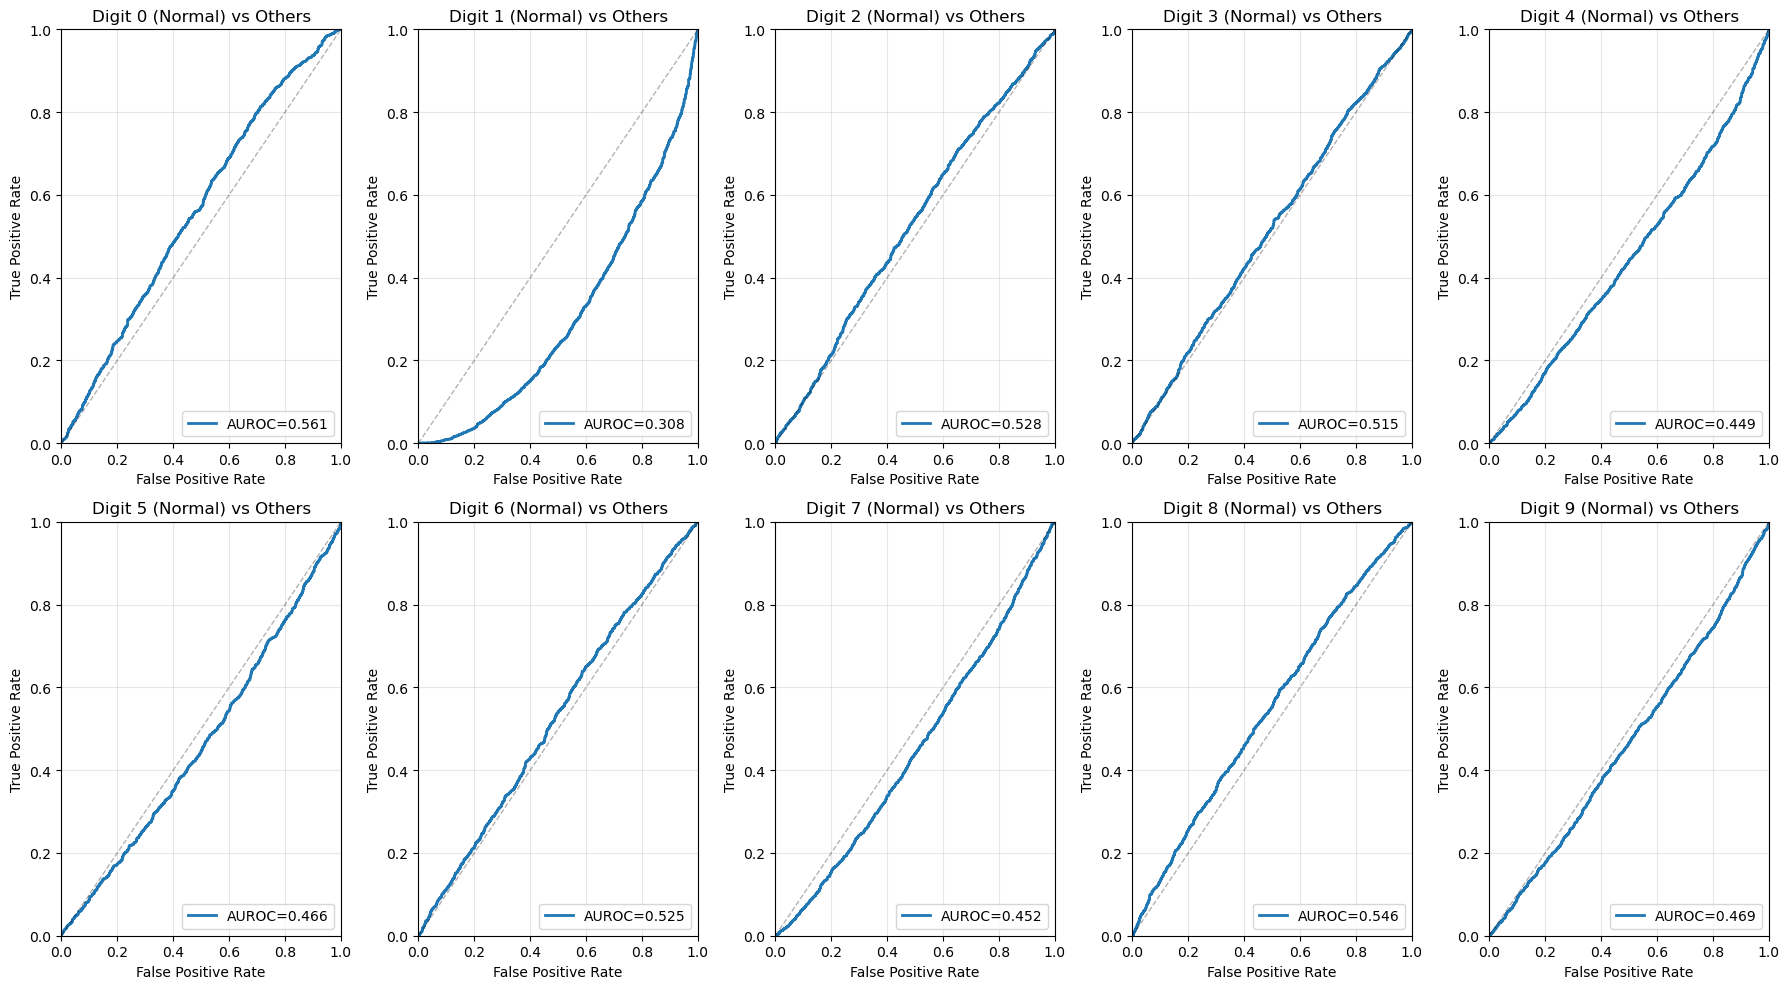

ROC curves plot saved to test_results/roc_curves/all_roc_curves.png


In [16]:
# Plot ROC curves for all models in one figure
fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()

for idx, digit in enumerate(sorted(all_results.keys())):
    ax = axes[idx]
    results = all_results[digit]
    
    ax.plot(results['fpr'], results['tpr'], lw=2, label=f'AUROC={results["auroc"]:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Digit {digit} (Normal) vs Others')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
roc_plot_path = ROC_DIR / 'all_roc_curves.png'
plt.savefig(roc_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC curves plot saved to {roc_plot_path}")

## Visualize Anomaly Score Distributions

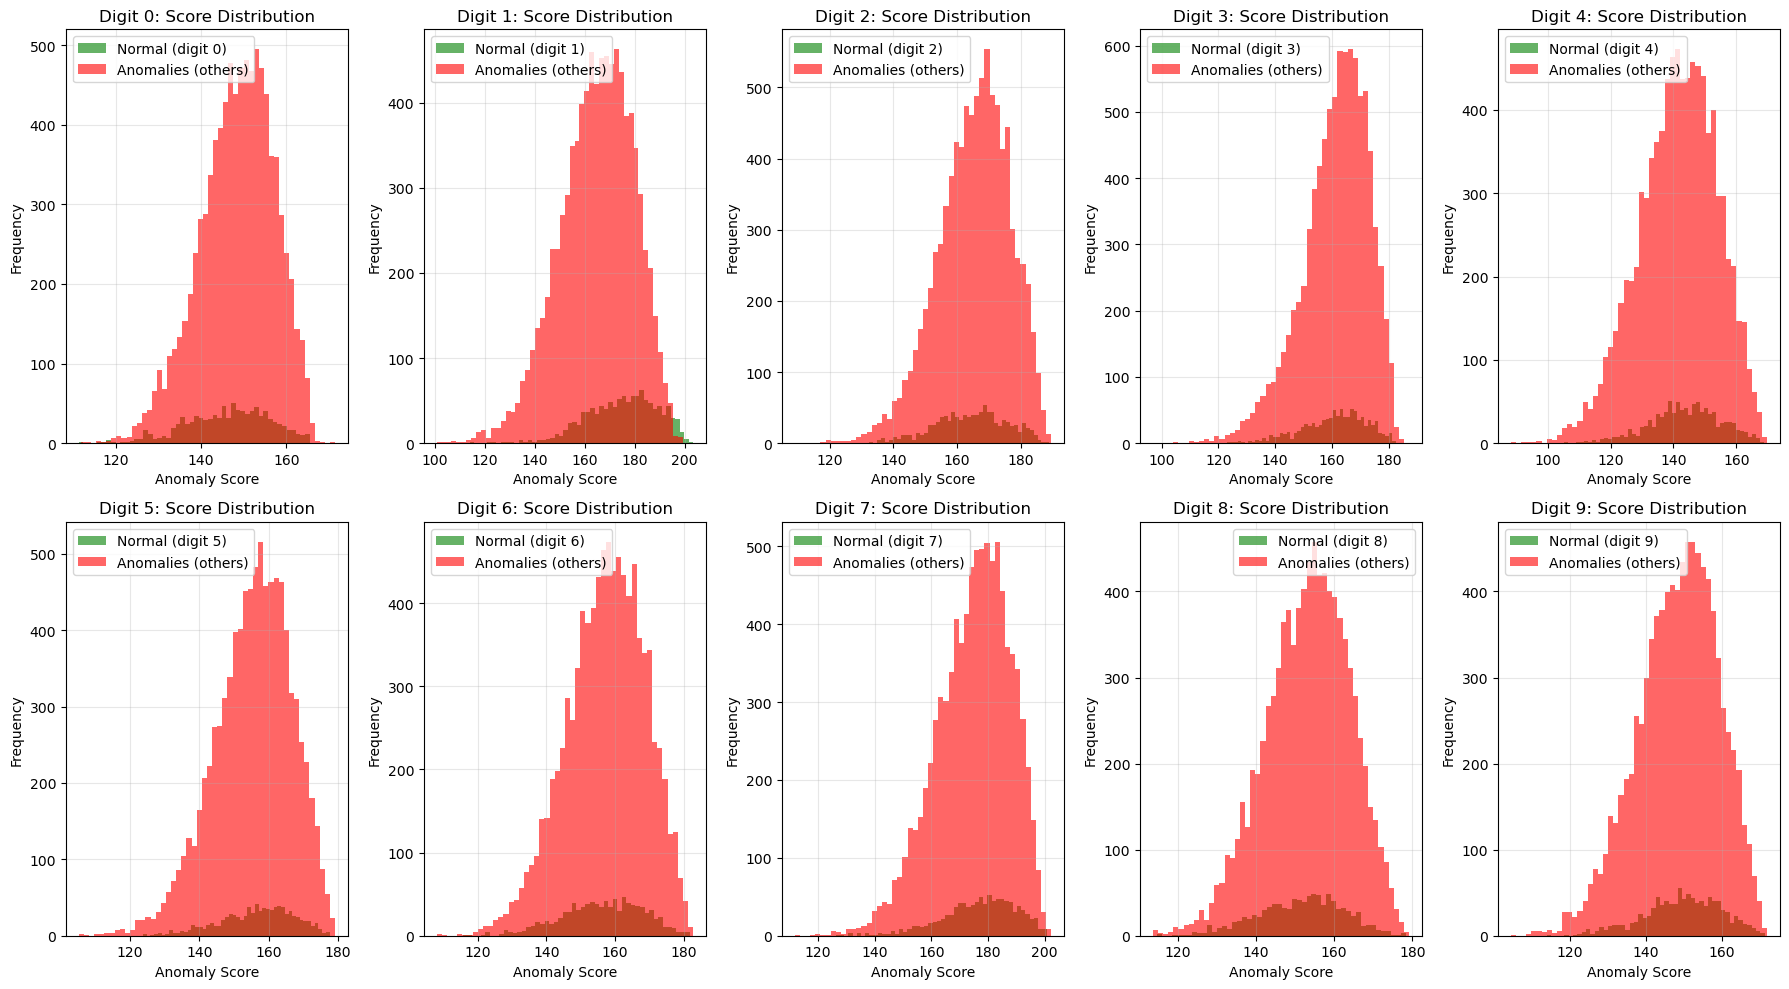

Anomaly distribution plots saved to test_results/roc_curves/all_anomaly_distributions.png


In [17]:
# Plot anomaly score distributions for all models
fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()

for idx, digit in enumerate(sorted(all_results.keys())):
    ax = axes[idx]
    results = all_results[digit]
    
    normal_scores = results['anomaly_scores'][results['binary_labels'] == 0]
    anomaly_scores = results['anomaly_scores'][results['binary_labels'] == 1]
    
    ax.hist(normal_scores, bins=50, alpha=0.6, label=f'Normal (digit {digit})', color='green')
    ax.hist(anomaly_scores, bins=50, alpha=0.6, label='Anomalies (others)', color='red')
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Digit {digit}: Score Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
dist_plot_path = ROC_DIR / 'all_anomaly_distributions.png'
plt.savefig(dist_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Anomaly distribution plots saved to {dist_plot_path}")

## AUROC Comparison Bar Chart

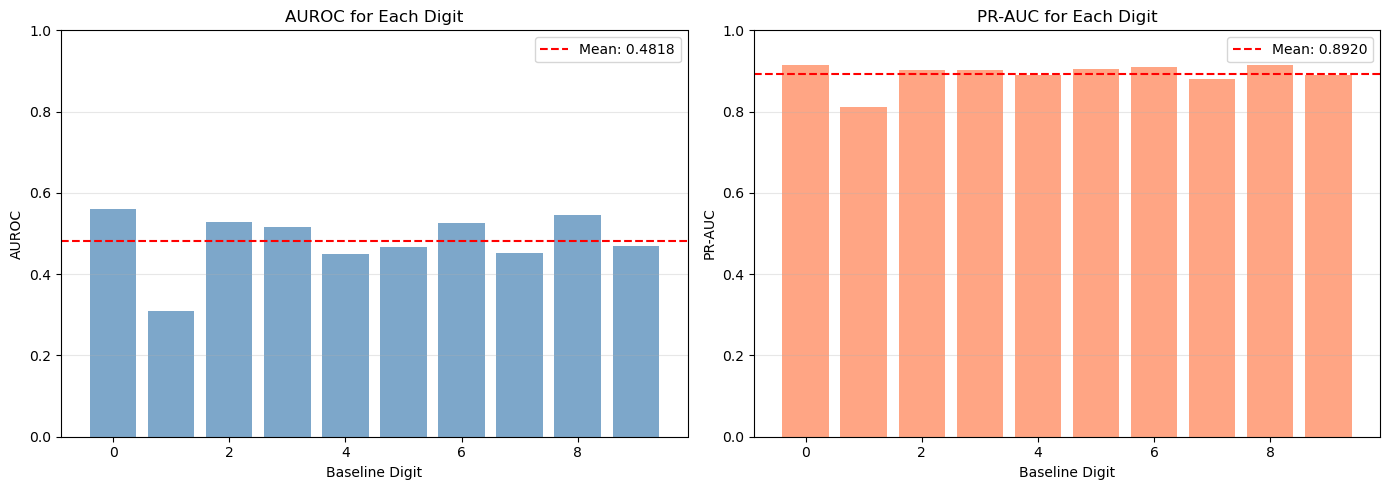

Comparison plot saved to test_results/roc_curves/auroc_pr_auc_comparison.png


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# AUROC comparison
digits = sorted(all_results.keys())
aurocs = [all_results[d]['auroc'] for d in digits]
pr_aucs = [all_results[d]['pr_auc'] for d in digits]

ax1.bar(digits, aurocs, color='steelblue', alpha=0.7)
ax1.axhline(y=np.mean(aurocs), color='red', linestyle='--', label=f'Mean: {np.mean(aurocs):.4f}')
ax1.set_xlabel('Baseline Digit')
ax1.set_ylabel('AUROC')
ax1.set_title('AUROC for Each Digit')
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

# PR-AUC comparison
ax2.bar(digits, pr_aucs, color='coral', alpha=0.7)
ax2.axhline(y=np.mean(pr_aucs), color='red', linestyle='--', label=f'Mean: {np.mean(pr_aucs):.4f}')
ax2.set_xlabel('Baseline Digit')
ax2.set_ylabel('PR-AUC')
ax2.set_title('PR-AUC for Each Digit')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

plt.tight_layout()
comparison_path = ROC_DIR / 'auroc_pr_auc_comparison.png'
plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Comparison plot saved to {comparison_path}")

## Export Results as CSV

In [19]:
import pandas as pd

# Create detailed results DataFrame
results_list = []
for digit in sorted(all_results.keys()):
    results_list.append({
        'Digit': digit,
        'AUROC': all_results[digit]['auroc'],
        'PR-AUC': all_results[digit]['pr_auc'],
        'TPR@FPR=1%': all_results[digit]['tpr_at_fpr_1pct'],
        'TPR@FPR=5%': all_results[digit]['tpr_at_fpr_5pct'],
        'Normal_Mean_Score': all_results[digit]['normal_mean'],
        'Anomaly_Mean_Score': all_results[digit]['anomaly_mean'],
        'Score_Separation': all_results[digit]['anomaly_mean'] - all_results[digit]['normal_mean'],
    })

df = pd.DataFrame(results_list)

# Save to CSV
csv_path = SUMMARY_DIR / 'model_performance.csv'
df.to_csv(csv_path, index=False)
print(f"Results saved to CSV: {csv_path}")
print("\n" + str(df.to_string(index=False)))

Results saved to CSV: test_results/summary/model_performance.csv

 Digit    AUROC   PR-AUC  TPR@FPR=1%  TPR@FPR=5%  Normal_Mean_Score  Anomaly_Mean_Score  Score_Separation
     0 0.560905 0.914742    0.009534    0.055765         146.308412          148.449565          2.141153
     1 0.308393 0.810450    0.000226    0.001241         175.012104          164.852144        -10.159960
     2 0.527675 0.902843    0.014050    0.051740         164.175504          165.128023          0.952519
     3 0.515057 0.902842    0.010567    0.052169         160.675588          161.191320          0.515732
     4 0.448518 0.889019    0.006432    0.035485         143.717354          141.356012         -2.361342
     5 0.465861 0.904349    0.012846    0.045674         156.719252          155.358818         -1.360434
     6 0.524850 0.909795    0.008737    0.063703         156.163950          157.223245          1.059295
     7 0.451941 0.880331    0.003790    0.024744         176.769774          174.69449

## Summary

In [20]:
print(f"\n{'='*70}")
print("TESTING COMPLETE")
print(f"{'='*70}")
print(f"\nResults saved to: {RESULTS_DIR}")
print(f"\nDirectory structure:")
print(f"  - ROC curves: {ROC_DIR}")
print(f"  - AUROC scores: {AUROC_DIR}")
print(f"  - Per-digit metrics: {METRICS_DIR}")
print(f"  - Summary reports: {SUMMARY_DIR}")
print(f"\nKey findings:")
print(f"  - Mean AUROC: {summary_dict['mean_auroc']:.4f}")
print(f"  - Std AUROC: {summary_dict['std_auroc']:.4f}")
print(f"  - Mean PR-AUC: {summary_dict['mean_pr_auc']:.4f}")
print(f"\nBest performing digit: {sorted(all_results.keys(), key=lambda x: all_results[x]['auroc'], reverse=True)[0]}")
print(f"Worst performing digit: {sorted(all_results.keys(), key=lambda x: all_results[x]['auroc'])[0]}")
print(f"{'='*70}")


TESTING COMPLETE

Results saved to: test_results

Directory structure:
  - ROC curves: test_results/roc_curves
  - AUROC scores: test_results/auroc_scores
  - Per-digit metrics: test_results/metrics_per_digit
  - Summary reports: test_results/summary

Key findings:
  - Mean AUROC: 0.4818
  - Std AUROC: 0.0692
  - Mean PR-AUC: 0.8920

Best performing digit: 0
Worst performing digit: 1
